In [26]:
from typing import Optional

import numpy as np

import torch
import torchopt

import nll_to_po.models.dn_policy as Policy
import nll_to_po.models.reward_network as RM
from nll_to_po.training.utils import (
    set_seed_everywhere,
)
import nll_to_po.training.loss as L
import nll_to_po.training.reward as R

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.5)
sns.set_palette("colorblind")
sns.despine()

<Figure size 640x480 with 0 Axes>

### Data utils

In [2]:
def generate_data_linear_noloader(
    input_dim: int,
    output_dim: int,
    train_size: int = 100,
    val_size: int = 100,
    test_size: int = 100,
    init_dist_loc: Optional[float] = None,
    init_dist_scale: Optional[float] = None,
    init_dist_n_samples: int = 1,
    A: Optional[torch.Tensor] = None,
):
    assert input_dim == output_dim, (
        f"input dim {input_dim} is different from output dim {output_dim}"
    )

    set_seed_everywhere(seed=np.random.randint(0, 1e6))

    # resample parameters
    if A is None:
        A = torch.eye(output_dim)
    if init_dist_loc is None:
        init_dist_loc = np.random.uniform(-6.0, 6.0)
    if init_dist_scale is None:
        init_dist_scale = np.random.uniform(0.1, 2.5)

    # Generate input data (uniform in -5,5)
    X_unique = torch.rand((train_size + val_size + test_size, input_dim)) * 10 - 5

    # For training data: repeat each unique X multiple times
    X_train_unique = X_unique[:train_size]
    X_train = X_train_unique.repeat_interleave(init_dist_n_samples, dim=0)

    # Compute mean for training X and sample multiple y values
    mean_y_train = X_train_unique @ A.T + init_dist_loc
    mean_y_train_expanded = mean_y_train.repeat_interleave(init_dist_n_samples, dim=0)
    y_train = (
        mean_y_train_expanded
        + torch.randn(X_train.shape[0], output_dim) * init_dist_scale
    )
    # std_y_train = torch.full_like(mean_y_train_expanded, init_dist_scale)

    # For validation data: use unique X without repetition
    X_val = X_unique[train_size : train_size + val_size]
    mean_y_val = X_val @ A.T + init_dist_loc
    y_val = mean_y_val + torch.randn(X_val.shape[0], output_dim) * init_dist_scale
    # std_y_val = torch.full_like(mean_y_val, init_dist_scale)

    # For test data: use unique X without repetition
    X_test = X_unique[train_size + val_size :]
    mean_y_test = X_test @ A.T + init_dist_loc
    y_test = mean_y_test + torch.randn(X_test.shape[0], output_dim) * init_dist_scale
    # std_y_test = torch.full_like(mean_y_test, init_dist_scale)

    # Create DataLoaders
    # train_dataset = torch.utils.data.TensorDataset(
    #     X_train, y_train, mean_y_train_expanded, std_y_train
    # )
    # train_dataloader = torch.utils.data.DataLoader(
    #     train_dataset, batch_size=X_train.shape[0], shuffle=True
    # )
    # val_dataset = torch.utils.data.TensorDataset(X_val, y_val, mean_y_val, std_y_val)
    # val_dataloader = torch.utils.data.DataLoader(
    #     val_dataset, batch_size=X_val.shape[0], shuffle=False
    # )
    # test_dataset = torch.utils.data.TensorDataset(
    #     X_test, y_test, mean_y_test, std_y_test
    # )
    # test_dataloader = torch.utils.data.DataLoader(
    #     test_dataset, batch_size=X_test.shape[0], shuffle=False
    # )

    return X_train, y_train, X_val, y_val, X_test, y_test


def generate_data_linear(
    input_dim: int,
    output_dim: int,
    train_size: int = 100,
    val_size: int = 100,
    test_size: int = 100,
    init_dist_loc: Optional[float] = None,
    init_dist_scale: Optional[float] = None,
    init_dist_n_samples: int = 1,
    A: Optional[torch.Tensor] = None,
):
    assert input_dim == output_dim, (
        f"input dim {input_dim} is different from output dim {output_dim}"
    )

    set_seed_everywhere(seed=np.random.randint(0, 1e6))

    # resample parameters
    if A is None:
        A = torch.eye(output_dim)
    if init_dist_loc is None:
        init_dist_loc = np.random.uniform(-6.0, 6.0)
    if init_dist_scale is None:
        init_dist_scale = np.random.uniform(0.1, 2.5)

    # Generate input data (uniform in -5,5)
    X_unique = torch.rand((train_size + val_size + test_size, input_dim)) * 10 - 5

    # For training data: repeat each unique X multiple times
    X_train_unique = X_unique[:train_size]
    X_train = X_train_unique.repeat_interleave(init_dist_n_samples, dim=0)

    # Compute mean for training X and sample multiple y values
    mean_y_train = X_train_unique @ A.T + init_dist_loc
    mean_y_train_expanded = mean_y_train.repeat_interleave(init_dist_n_samples, dim=0)
    y_train = (
        mean_y_train_expanded
        + torch.randn(X_train.shape[0], output_dim) * init_dist_scale
    )
    std_y_train = torch.full_like(mean_y_train_expanded, init_dist_scale)

    # For validation data: use unique X without repetition
    X_val = X_unique[train_size : train_size + val_size]
    mean_y_val = X_val @ A.T + init_dist_loc
    y_val = mean_y_val + torch.randn(X_val.shape[0], output_dim) * init_dist_scale
    std_y_val = torch.full_like(mean_y_val, init_dist_scale)

    # For test data: use unique X without repetition
    X_test = X_unique[train_size + val_size :]
    mean_y_test = X_test @ A.T + init_dist_loc
    y_test = mean_y_test + torch.randn(X_test.shape[0], output_dim) * init_dist_scale
    std_y_test = torch.full_like(mean_y_test, init_dist_scale)

    # Create DataLoaders
    train_dataset = torch.utils.data.TensorDataset(
        X_train, y_train, mean_y_train_expanded, std_y_train
    )
    train_dataloader = torch.utils.data.DataLoader(
        train_dataset, batch_size=X_train.shape[0], shuffle=True
    )
    val_dataset = torch.utils.data.TensorDataset(X_val, y_val, mean_y_val, std_y_val)
    val_dataloader = torch.utils.data.DataLoader(
        val_dataset, batch_size=X_val.shape[0], shuffle=False
    )
    test_dataset = torch.utils.data.TensorDataset(
        X_test, y_test, mean_y_test, std_y_test
    )
    test_dataloader = torch.utils.data.DataLoader(
        test_dataset, batch_size=X_test.shape[0], shuffle=False
    )

    return (
        train_dataloader,
        val_dataloader,
        test_dataloader,
        {
            "init_dist_loc": init_dist_loc,
            "init_dist_scale": init_dist_scale,
            "init_dist_n_samples": init_dist_n_samples,
        },
    )


def generate_data_single_point(
    input_dim: int,
    output_dim: int,
    init_dist_loc: Optional[float] = None,
    init_dist_scale: Optional[float] = None,
    init_dist_n_samples: Optional[int] = None,
):
    set_seed_everywhere(seed=np.random.randint(0, 1e6))

    # resample parameters
    if not init_dist_loc:
        init_dist_loc = np.random.uniform(-5.0, 5.0)
    if not init_dist_scale:
        init_dist_scale = np.random.uniform(0.5, 1.5)
    if not init_dist_n_samples:
        init_dist_n_samples = np.random.randint(1, 100)

    # Generate new random data for each experiment
    X = torch.randn(1, input_dim)
    mean_y = torch.ones((1, output_dim)) * init_dist_loc
    mean_y_expanded = mean_y.repeat_interleave(init_dist_n_samples, dim=0)
    y = mean_y_expanded + torch.randn(init_dist_n_samples, output_dim) * init_dist_scale
    X = X.repeat(init_dist_n_samples, 1)  # Repeat X for each sample
    batch_size = X.shape[0]
    std_y = torch.full_like(mean_y_expanded, init_dist_scale)

    # Create a DataLoader
    train_dataset = torch.utils.data.TensorDataset(X, y, mean_y_expanded, std_y)
    train_dataloader = torch.utils.data.DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True
    )

    return (
        train_dataloader,
        None,
        None,
        {
            "init_dist_loc": init_dist_loc,
            "init_dist_scale": init_dist_scale,
            "init_dist_n_samples": init_dist_n_samples,
        },
    )

### Generate data

In [71]:
input_dim: int = 2
output_dim: int = 2

init_dist_loc: float = 6.0
init_dist_scale: float = 1.75
init_dist_n_samples: int = 10
train_size: int = 100
val_size: int = 100

# A: torch.Tensor = torch.randn((output_dim, input_dim))
A: torch.Tensor = torch.eye(output_dim)

X_train, y_train, _, _, _, _ = generate_data_linear_noloader(
    input_dim=input_dim,
    output_dim=output_dim,
    train_size=train_size,
    val_size=val_size,
    init_dist_loc=init_dist_loc,
    init_dist_scale=init_dist_scale,
    init_dist_n_samples=init_dist_n_samples,
    A=A,
)

### Torchopt

In [ ]:
# -----------------------
# Helper: make functional params with grad
# -----------------------
from tqdm import tqdm


def make_functional_with_grads(module):
    params = dict(module.named_parameters())
    params = [p.detach().clone().requires_grad_(True) for _, p in params.items()]
    return module, params


# -----------------------
# Main bilevel routine
# -----------------------
def run_bilevel_optimization(
    n_outer_epochs=10,
    n_inner_epochs=5,
    inner_lr: float = 1e-3,
    outer_lr: float = 1e-3,
    device: str = "cpu",
    input_dim: int = 2,
    output_dim: int = 2,
    hidden_sizes: list[int] = [64, 64],
    fixed_logstd: bool = False,
    entropy_weight: float = 1.0,
    n_generations: int = 5,
):
    # reward
    reward_network = RM.RewardMLPMahalanobisDiag(input_dim).to(device)
    reward_model, reward_params = make_functional_with_grads(reward_network)

    # policy
    policy = Policy.MLPPolicy(input_dim, output_dim, hidden_sizes, fixed_logstd).to(
        device
    )
    policy_model, policy_params = make_functional_with_grads(policy)

    # reward loss: nll
    nll_loss = L.FuncNLL()

    # Tracking
    outer_losses = []
    inner_losses = []
    inner_rewards = []
    U_coeff = [reward_network.param.item()]
    U_coeff_grad = [0.0]

    # reward optimizer
    outer_optimizer = torchopt.sgd(lr=outer_lr)
    outer_opt_state = outer_optimizer.init(reward_params)

    def outer_loss_fn(reward_params, policy_params, X, y):
        reward_params_dict = dict(
            zip(dict(reward_model.named_parameters()).keys(), reward_params)
        )
        reward_fn = R.FuncRewardNetwork(
            reward_model=reward_model, reward_params=reward_params_dict
        )

        # policy loss
        pg_loss = L.FuncPG(
            reward_fn=reward_fn,
            n_generations=n_generations,
            entropy_weight=entropy_weight,
        )

        def inner_loss_fn(policy_params, X, y):
            # Reconstruct params dict (for functional_call)
            policy_params_dict = dict(
                zip(dict(policy_model.named_parameters()).keys(), policy_params)
            )
            loss, _ = pg_loss.compute_loss(
                policy_model=policy_model,
                policy_params=policy_params_dict,
                X=X,
                y=y,
                reward_model=reward_model,
                reward_params=reward_params_dict,
            )
            return loss

        # Create differentiable SGD optimizer
        inner_optimizer = torchopt.sgd(lr=inner_lr)  # , eps=1e-8)
        inner_opt_state = inner_optimizer.init(policy_params)

        # Inner loop with torchopt
        inner_losses_per_iter = []
        inner_rewards_per_iter = []
        for inner_step in range(n_inner_epochs):
            # Compute gradients and update
            grads = torch.func.grad(inner_loss_fn)(
                policy_params,
                X,
                y,
            )
            # Clip gradients to prevent explosion
            grads = [torch.clamp(g, -1.0, 1.0) for g in grads]
            updates, inner_opt_state = inner_optimizer.update(
                grads, inner_opt_state, inplace=False
            )
            policy_params = torchopt.apply_updates(
                policy_params, updates, inplace=False
            )

            # Track loss
            with torch.no_grad():
                # Reconstruct params dict (for functional_call)
                policy_params_dict = dict(
                    zip(dict(policy_model.named_parameters()).keys(), policy_params)
                )
                inner_loss, metrics = pg_loss.compute_loss(
                    policy_model,
                    policy_params_dict,
                    X,
                    y,
                    reward_model=reward_model,
                    reward_params=reward_params_dict,
                )
                inner_losses_per_iter.append(float(inner_loss))
                inner_rewards_per_iter.append(metrics["reward_mean"])
        inner_losses.append(inner_losses_per_iter)
        inner_rewards.append(inner_rewards_per_iter)

        # outer loss
        loss, _ = nll_loss.compute_loss(
            policy_model=policy_model,
            policy_params=policy_params_dict,
            X=X,
            y=y,
        )
        outer_losses.append(float(loss))
        return loss

    for outer_epoch in tqdm(range(n_outer_epochs)):
        # -----------------------
        # Outer loop: update reward params
        # -----------------------

        # Reset reward params gradient
        reward_params = [p.detach().clone().requires_grad_(True) for p in reward_params]

        # Reset policy each outer iteration
        _, policy_params = make_functional_with_grads(policy)

        # Compute gradients and update
        grads = torch.func.grad(outer_loss_fn)(
            reward_params,
            policy_params,
            X_train.to(device),
            y_train.to(device),
        )
        # Clip gradients to prevent explosion
        grads = [torch.clamp(g, -1.0, 1.0) for g in grads]
        updates, outer_opt_state = outer_optimizer.update(
            grads, outer_opt_state, inplace=False
        )

        reward_params = torchopt.apply_updates(reward_params, updates)

        U_coeff_grad.append(grads[0].item())

        # track the attribute param of the reward network
        U_coeff.append(reward_params[0].item())
    return outer_losses, inner_losses, inner_rewards, U_coeff, U_coeff_grad

In [131]:
# Policy architecture
hidden_sizes: list[int] = [64, 64]
fixed_logstd: bool = False

# PG
entropy_weight: float = 1.5
n_generations: int = 5

n_outer_epochs: int = 200
n_inner_epochs: int = 100
inner_lr: float = 1e-3
outer_lr: float = 1e-2
device: str = "cuda:0"

U_star = (entropy_weight) / (2 * (init_dist_scale**2))

Running experiment 1/5...


  0%|          | 1/200 [00:01<06:01,  1.82s/it]


Experiment 1 crashed: Expected parameter loc (Tensor of shape (1000, 2)) of distribution Normal(loc: torch.Size([1000, 2]), scale: torch.Size([1000, 2])) to satisfy the constraint Real(), but found invalid values:
GradTrackingTensor(lvl=1, value=
    tensor([[nan, nan],
            [nan, nan],
            [nan, nan],
            ...,
            [nan, nan],
            [nan, nan],
            [nan, nan]], device='cuda:0')
)
Crashes so far: 1/10
Running experiment 2/5...


  0%|          | 1/200 [00:01<05:53,  1.78s/it]


Experiment 2 crashed: Expected parameter loc (Tensor of shape (1000, 2)) of distribution Normal(loc: torch.Size([1000, 2]), scale: torch.Size([1000, 2])) to satisfy the constraint Real(), but found invalid values:
GradTrackingTensor(lvl=1, value=
    tensor([[nan, nan],
            [nan, nan],
            [nan, nan],
            ...,
            [nan, nan],
            [nan, nan],
            [nan, nan]], device='cuda:0')
)
Crashes so far: 2/10
Running experiment 3/5...


...

  0%|          | 1/200 [00:01<06:04,  1.83s/it]


Experiment 4 crashed: Expected parameter loc (Tensor of shape (1000, 2)) of distribution Normal(loc: torch.Size([1000, 2]), scale: torch.Size([1000, 2])) to satisfy the constraint Real(), but found invalid values:
GradTrackingTensor(lvl=1, value=
    tensor([[nan, nan],
            [nan, nan],
            [nan, nan],
            ...,
            [nan, nan],
            [nan, nan],
            [nan, nan]], device='cuda:0')
)
Crashes so far: 4/10
Running experiment 5/5...


  0%|          | 1/200 [00:01<05:32,  1.67s/it]

Experiment 5 crashed: Expected parameter loc (Tensor of shape (1000, 2)) of distribution Normal(loc: torch.Size([1000, 2]), scale: torch.Size([1000, 2])) to satisfy the constraint Real(), but found invalid values:
GradTrackingTensor(lvl=1, value=
    tensor([[nan, nan],
            [nan, nan],
            [nan, nan],
            ...,
            [nan, nan],
            [nan, nan],
            [nan, nan]], device='cuda:0')
)
Crashes so far: 5/10
Completed 0 successful runs out of 5 attempts.


TypeError: object of type 'numpy.float64' has no len()

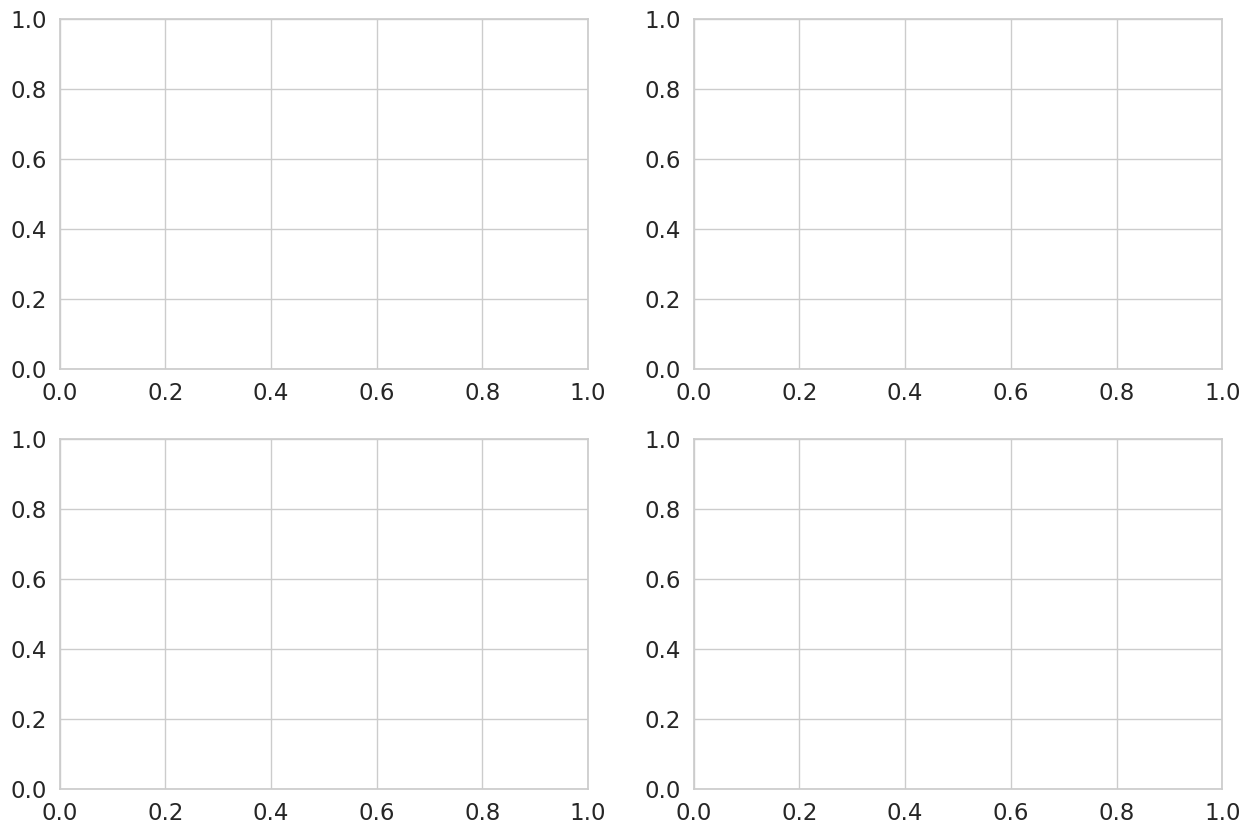

In [132]:
import warnings

warnings.filterwarnings("ignore")

# Experiment parameters
max_repetitions = 5
max_tolerated_crashes = 10

# Storage for all runs
all_outer_losses = []
all_inner_losses = []
all_inner_rewards = []
all_U_coeff = []
all_U_coeff_grad = []

successful_runs = 0
crashes = 0

for rep in range(max_repetitions):
    if crashes >= max_tolerated_crashes:
        print(
            f"Maximum tolerated crashes ({max_tolerated_crashes}) reached. Stopping experiments."
        )
        break

    try:
        print(f"Running experiment {rep + 1}/{max_repetitions}...")

        # Run the bilevel optimization
        outer_losses, inner_losses, inner_rewards, U_coeff, U_coeff_grad = (
            run_bilevel_optimization(
                n_outer_epochs=n_outer_epochs,
                n_inner_epochs=n_inner_epochs,
                inner_lr=inner_lr,
                outer_lr=outer_lr,
                device=device,
                input_dim=input_dim,
                output_dim=output_dim,
                hidden_sizes=hidden_sizes,
                fixed_logstd=fixed_logstd,
                entropy_weight=entropy_weight,
                n_generations=n_generations,
            )
        )

        # Store results
        all_outer_losses.append(outer_losses)
        all_inner_losses.append(inner_losses)
        all_inner_rewards.append(inner_rewards)
        all_U_coeff.append(U_coeff)
        all_U_coeff_grad.append(U_coeff_grad)

        successful_runs += 1
        print(f"Experiment {rep + 1} completed successfully.")

    except Exception as e:
        crashes += 1
        print(f"Experiment {rep + 1} crashed: {str(e)}")
        print(f"Crashes so far: {crashes}/{max_tolerated_crashes}")
        continue

print(f"Completed {successful_runs} successful runs out of {max_repetitions} attempts.")

# Convert to numpy arrays for easier computation
all_outer_losses = np.array(all_outer_losses)
all_U_coeff = np.array(all_U_coeff)
all_U_coeff_grad = np.array(all_U_coeff_grad)

# Flatten inner rewards for averaging
all_inner_rewards_flat = []
for run in all_inner_rewards:
    flat_rewards = []
    for outer_epoch in run:
        flat_rewards.extend(outer_epoch)
    all_inner_rewards_flat.append(flat_rewards)
all_inner_rewards_flat = np.array(all_inner_rewards_flat)

# Compute statistics
outer_losses_mean = np.mean(all_outer_losses, axis=0)
outer_losses_std = np.std(all_outer_losses, axis=0)
outer_losses_se = outer_losses_std / np.sqrt(successful_runs)

U_coeff_mean = np.mean(all_U_coeff, axis=0)
U_coeff_std = np.std(all_U_coeff, axis=0)
U_coeff_se = U_coeff_std / np.sqrt(successful_runs)

U_coeff_grad_mean = np.mean(all_U_coeff_grad, axis=0)
U_coeff_grad_std = np.std(all_U_coeff_grad, axis=0)
U_coeff_grad_se = U_coeff_grad_std / np.sqrt(successful_runs)

inner_rewards_mean = np.mean(all_inner_rewards_flat, axis=0)
inner_rewards_std = np.std(all_inner_rewards_flat, axis=0)
inner_rewards_se = inner_rewards_std / np.sqrt(successful_runs)

# Plot results with error bars
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Plot outer losses
epochs_outer = range(len(outer_losses_mean))
ax1.plot(epochs_outer, outer_losses_mean, "b-o", linewidth=2, markersize=6)
ax1.fill_between(
    epochs_outer,
    outer_losses_mean - outer_losses_se,
    outer_losses_mean + outer_losses_se,
    alpha=0.3,
    color="blue",
)
ax1.set_xlabel("Outer epoch")
ax1.set_ylabel("Loss")
ax1.set_title(f"Outer Loss (NLL) - {successful_runs} runs")
ax1.grid(True, alpha=0.3)

# Plot inner rewards
epochs_inner = range(len(inner_rewards_mean))
ax2.plot(epochs_inner, inner_rewards_mean, "b-", linewidth=2)
ax2.fill_between(
    epochs_inner,
    inner_rewards_mean - inner_rewards_se,
    inner_rewards_mean + inner_rewards_se,
    alpha=0.3,
    color="blue",
)

# Add vertical dotted lines to separate outer epochs
for i in range(1, n_outer_epochs):
    ax2.axvline(x=i * n_inner_epochs - 0.5, color="black", linestyle="--", alpha=0.3)

ax2.set_xlabel("Inner epoch")
ax2.set_ylabel("Reward")
ax2.set_title(f"Inner Rewards - {successful_runs} runs")
ax2.grid(True, alpha=0.3)

# Plot U coefficient
epochs_U = range(len(U_coeff_mean))
ax3.plot(epochs_U, U_coeff_mean, "g-o", linewidth=2, markersize=6)
ax3.fill_between(
    epochs_U,
    U_coeff_mean - U_coeff_se,
    U_coeff_mean + U_coeff_se,
    alpha=0.3,
    color="green",
)
ax3.axhline(
    y=U_star, color="red", linestyle="--", linewidth=2, label=f"U* = {U_star:.4f}"
)
ax3.set_xlabel("Outer epoch")
ax3.set_ylabel("U coefficient")
ax3.set_title(f"Reward Network Parameter - {successful_runs} runs")
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot U coefficient gradients
ax4.plot(epochs_U, U_coeff_grad_mean, "r-o", linewidth=2, markersize=6)
ax4.fill_between(
    epochs_U,
    U_coeff_grad_mean - U_coeff_grad_se,
    U_coeff_grad_mean + U_coeff_grad_se,
    alpha=0.3,
    color="red",
)
ax4.set_xlabel("Outer epoch")
ax4.set_ylabel("Gradient")
ax4.set_title(f"U_coeff Gradient - {successful_runs} runs")
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal statistics after {successful_runs} successful runs:")
print(f"Final U coefficient: {U_coeff_mean[-1]:.4f} ± {U_coeff_se[-1]:.4f}")
print(f"Target U*: {U_star:.4f}")
print(f"Final outer loss: {outer_losses_mean[-1]:.4f} ± {outer_losses_se[-1]:.4f}")

In [70]:
all_U_coeff_grad

array([[ 0., nan],
       [ 0., nan],
       [ 0., nan],
       [ 0., nan],
       [ 0., nan]])